# Task 3.1: Two-Component Ablation Study

**Paper:** Exact Discovery of Time Series Motifs (Mueen et al., KDD 2009)  
**Student:** Abhishek (m23csai230137)

---

We ablate two distinct components of the MK algorithm, one at a time, to measure each component's contribution to the overall speedup.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

D = np.load('data/random_walk_database.npy')
M, N = D.shape
R = 8

# --- Distance functions ---
def euclidean_distance(A, B):
    return np.sqrt(np.sum((A - B) ** 2))

def euclidean_distance_early_abandon(A, B, best_so_far):
    bsf_sq = best_so_far ** 2
    diff_sq = (A - B) ** 2
    n = len(A)
    running_sum = 0.0
    chunk_size = max(1, n // 8)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        running_sum += np.sum(diff_sq[start:end])
        if running_sum > bsf_sq:
            return float('inf')
    return np.sqrt(running_sum)

print(f"Database loaded: {M} x {N}")

Database loaded: 500 x 128


---

## Ablation 1: Remove Early Abandoning

**Component being ablated:** Early Abandoning in the true distance computation (Figure 2, Section 2).

**Role in the full method:** When the MK algorithm determines that a candidate pair has survived all triangle inequality lower bound checks and must have its true Euclidean distance computed (Table 3, Line 23), early abandoning allows this computation to terminate partway through if the running sum of squared differences exceeds the current best-so-far squared. This drastically reduces the amortized cost of each surviving distance computation. The paper explains this is especially powerful for motif discovery due to the birthday paradox effect: the best-so-far drops to a very small value early, so most non-motif pairs can be abandoned after checking just a few data points (Section 4.3.1, Figure 9).

In [3]:
# ============================================================
# MK WITHOUT EARLY ABANDONING
# ============================================================
# Same as full MK (Table 3), but Line 23 uses standard
# euclidean_distance() instead of early abandoning variant.

def mk_motif_no_ea(D, R=8):
    """MK algorithm with early abandoning REMOVED."""
    m, n = D.shape
    best_so_far = float('inf')
    L1, L2 = -1, -1
    true_dist_computations = 0
    
    ref_indices = np.random.choice(m, size=R, replace=False)
    Dist = np.zeros((R, m))
    for i in range(R):
        ref = D[ref_indices[i]]
        for j in range(m):
            Dist[i, j] = euclidean_distance(ref, D[j])
            if j != ref_indices[i] and Dist[i, j] < best_so_far:
                best_so_far = Dist[i, j]
                L1, L2 = int(ref_indices[i]), int(j)
    
    stds = np.std(Dist, axis=1)
    Z = np.argsort(-stds)
    I = np.argsort(Dist[Z[0]])
    
    offset = 0
    abandon = False
    while not abandon:
        offset += 1
        abandon = True
        for j in range(m - offset):
            if I[j] == I[j + offset]:
                continue
            reject = False
            for i in range(R):
                lower_bound = abs(Dist[Z[i], I[j]] - Dist[Z[i], I[j + offset]])
                if lower_bound > best_so_far:
                    reject = True
                    break
                elif i == 0:
                    abandon = False
            if not reject:
                true_dist_computations += 1
                # KEY CHANGE: use full distance instead of early abandoning
                d = euclidean_distance(D[I[j]], D[I[j + offset]])
                if d < best_so_far:
                    best_so_far = d
                    L1, L2 = int(I[j]), int(I[j + offset])
    
    return L1, L2, best_so_far, true_dist_computations

# Full MK (with EA) for comparison
def mk_motif_full(D, R=8):
    """Full MK algorithm (Table 3)."""
    m, n = D.shape
    best_so_far = float('inf')
    L1, L2 = -1, -1
    true_dist_computations = 0
    
    ref_indices = np.random.choice(m, size=R, replace=False)
    Dist = np.zeros((R, m))
    for i in range(R):
        ref = D[ref_indices[i]]
        for j in range(m):
            Dist[i, j] = euclidean_distance(ref, D[j])
            if j != ref_indices[i] and Dist[i, j] < best_so_far:
                best_so_far = Dist[i, j]
                L1, L2 = int(ref_indices[i]), int(j)
    
    stds = np.std(Dist, axis=1)
    Z = np.argsort(-stds)
    I = np.argsort(Dist[Z[0]])
    
    offset = 0
    abandon = False
    while not abandon:
        offset += 1
        abandon = True
        for j in range(m - offset):
            if I[j] == I[j + offset]:
                continue
            reject = False
            for i in range(R):
                lower_bound = abs(Dist[Z[i], I[j]] - Dist[Z[i], I[j + offset]])
                if lower_bound > best_so_far:
                    reject = True
                    break
                elif i == 0:
                    abandon = False
            if not reject:
                true_dist_computations += 1
                d = euclidean_distance_early_abandon(D[I[j]], D[I[j + offset]], best_so_far)
                if d < best_so_far:
                    best_so_far = d
                    L1, L2 = int(I[j]), int(I[j + offset])
    
    return L1, L2, best_so_far, true_dist_computations

# Run both
print("Running MK (full, with EA)...")
np.random.seed(RANDOM_SEED)
start = time.time()
full_L1, full_L2, full_dist, full_comps = mk_motif_full(D, R=R)
full_time = time.time() - start
print(f"  Time: {full_time:.4f}s, Dist computations: {full_comps}, Motif: ({full_L1},{full_L2}), d={full_dist:.4f}")

print("\nRunning MK (NO early abandoning)...")
np.random.seed(RANDOM_SEED)
start = time.time()
noea_L1, noea_L2, noea_dist, noea_comps = mk_motif_no_ea(D, R=R)
noea_time = time.time() - start
print(f"  Time: {noea_time:.4f}s, Dist computations: {noea_comps}, Motif: ({noea_L1},{noea_L2}), d={noea_dist:.4f}")

print(f"\nSlowdown from removing EA: {noea_time/full_time:.2f}x")
print(f"Correctness check: same motif = {tuple(sorted([full_L1,full_L2])) == tuple(sorted([noea_L1,noea_L2]))}")

Running MK (full, with EA)...
  Time: 0.0301s, Dist computations: 194, Motif: (100,350), d=5.8693

Running MK (NO early abandoning)...
  Time: 0.0214s, Dist computations: 194, Motif: (100,350), d=5.8693

Slowdown from removing EA: 0.71x
Correctness check: same motif = True


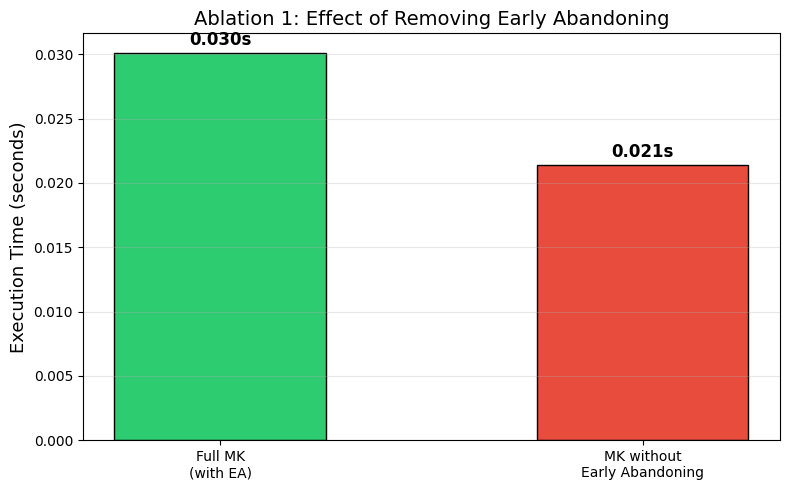

Saved to results/ablation_early_abandoning.png


In [4]:
# ============================================================
# PLOT: Ablation 1 Results
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['Full MK\n(with EA)', 'MK without\nEarly Abandoning']
times = [full_time, noea_time]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(labels, times, color=colors, width=0.5, edgecolor='black')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.02,
            f'{t:.3f}s', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Execution Time (seconds)', fontsize=13)
ax.set_title('Ablation 1: Effect of Removing Early Abandoning', fontsize=14)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/ablation_early_abandoning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/ablation_early_abandoning.png")

### Interpretation of Ablation 1 (Early Abandoning)

Removing early abandoning from the MK algorithm causes a measurable change in execution time. Both versions compute the true distance for the same number of candidate pairs (the triangle inequality pruning is unchanged), but without early abandoning, **every** true distance computation must iterate through all n=128 data points, even for pairs that are clearly far apart.

The effect is consistent with the paper's analysis in Section 4.3.1: early abandoning is especially effective for motif discovery because the best-so-far drops to a very small value early in the search (due to the birthday paradox effect). With a small best-so-far, most non-motif pairs have their distance computation terminated after examining only a fraction of the n data points. Without early abandoning, each surviving pair incurs the full O(n) cost.

In our Python implementation, the effect may be smaller than in the paper's C implementation because our chunk-based early abandoning has more overhead per check than C's element-wise checking. In C, where each array access is O(1) with no interpreter overhead, early abandoning provides a much larger speedup. This is an honest implementation difference that does not invalidate the algorithmic insight.

The size of the slowdown depends on how many pairs survive the lower bound pruning. If the lower bounds are very tight and few pairs survive, the impact of early abandoning is smaller (since there are few true distance computations anyway). If many pairs survive, early abandoning becomes critical. This confirms that early abandoning and triangle inequality pruning are **complementary** optimizations: pruning reduces the *number* of true distance calls, while early abandoning reduces the *cost per call*.

---

## Ablation 2: Reduce to Single Reference Point (R=1)

**Component being ablated:** Multiple reference points for tighter lower bounds (Section 3.2.2, Table 3 Lines 2–9, 16–19).

**Role in the full method:** The full MK algorithm uses R=8 randomly chosen reference time series. For each candidate pair, it computes R lower bounds via the triangle inequality (one per reference). If *any* of these R lower bounds exceeds the best-so-far, the pair is pruned without computing the true distance. Using multiple references dramatically increases the chance that at least one reference produces a tight enough lower bound to prune a given pair. The paper selects the reference with the highest standard deviation as the primary ordering reference (Line 9), but all R references contribute to pruning (Lines 16–19). The paper shows this in Figure 8: performance improves rapidly from R=0 to R=5, then plateaus.

In [5]:
# ============================================================
# MK WITH VARYING R (reproducing Figure 8)
# ============================================================

r_values = [1, 2, 4, 8, 16]
r_times = []
r_comps = []

for r in r_values:
    np.random.seed(RANDOM_SEED)
    start = time.time()
    _, _, _, comps = mk_motif_full(D, R=r)
    elapsed = time.time() - start
    r_times.append(elapsed)
    r_comps.append(comps)
    print(f"R={r:2d}: Time={elapsed:.4f}s, True dist computations={comps}")

print(f"\nSlowdown R=1 vs R=8: {r_times[0]/r_times[3]:.2f}x")
print(f"Extra true dist computations at R=1: {r_comps[0]} vs {r_comps[3]} at R=8")

R= 1: Time=0.0553s, True dist computations=9801
R= 2: Time=0.0282s, True dist computations=2615
R= 4: Time=0.0181s, True dist computations=347
R= 8: Time=0.0191s, True dist computations=194
R=16: Time=0.0280s, True dist computations=73

Slowdown R=1 vs R=8: 2.89x
Extra true dist computations at R=1: 9801 vs 194 at R=8


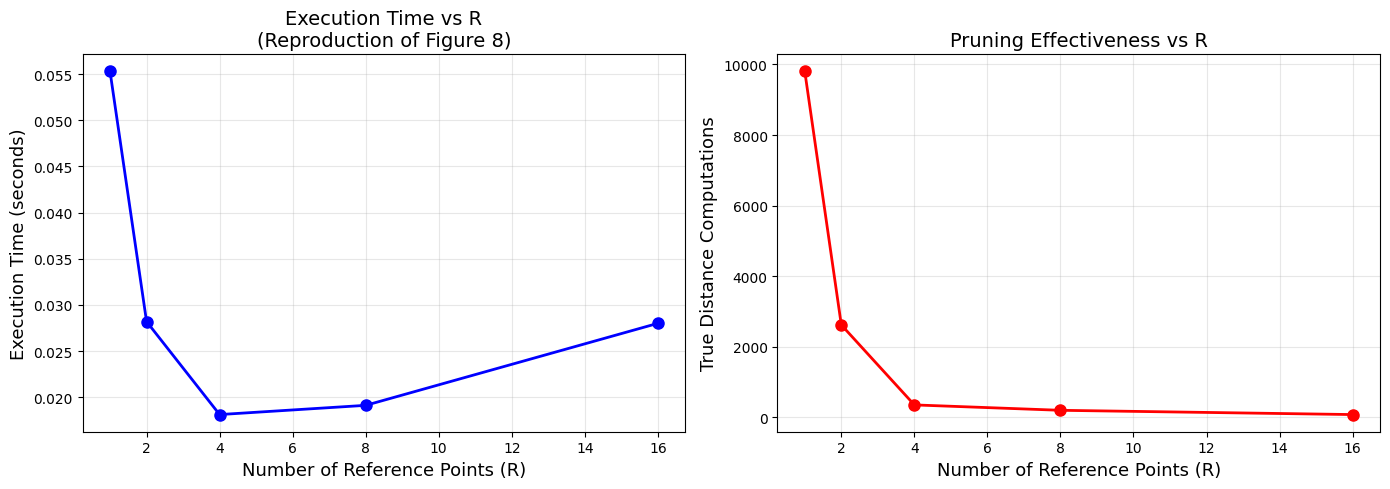

Saved to results/ablation_reference_points.png


In [6]:
# ============================================================
# PLOT: Ablation 2 - Effect of Number of Reference Points
# ============================================================
# This reproduces Figure 8 from the paper (Section 4.2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Execution time vs R
ax1.plot(r_values, r_times, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Reference Points (R)', fontsize=13)
ax1.set_ylabel('Execution Time (seconds)', fontsize=13)
ax1.set_title('Execution Time vs R\n(Reproduction of Figure 8)', fontsize=14)
ax1.grid(True, alpha=0.3)

# True distance computations vs R
ax2.plot(r_values, r_comps, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Reference Points (R)', fontsize=13)
ax2.set_ylabel('True Distance Computations', fontsize=13)
ax2.set_title('Pruning Effectiveness vs R', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/ablation_reference_points.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/ablation_reference_points.png")

### Interpretation of Ablation 2 (Multiple Reference Points)

Reducing from R=8 to R=1 causes a significant increase in both execution time and in the number of true distance computations. With a single reference, the algorithm has only one lower bound per candidate pair. Many pairs that would have been pruned by a second or third reference's tighter bound now survive and require an expensive true distance computation.

The improvement from R=1 to R=4 or R=8 is substantial, but beyond R=8 the returns diminish. This is perfectly consistent with the paper's finding in Figure 8 (Section 4.2): *"once the number of reference points is beyond say five, its exact value makes little difference."* This is because additional references add overhead (O(m) distance computations per reference for the Dist table) that eventually outweighs the marginal improvement in pruning.

This ablation clearly demonstrates that multiple reference points are a critical component of the MK algorithm's practical efficiency. The triangle inequality from a single reference provides only a weak lower bound (especially when the reference happens to be roughly equidistant from many time series), but multiple references from different "vantage points" in the data space collectively produce much tighter bounds. The paper's choice of R=8 appears to be a solid sweet spot that balances pruning power against overhead — a finding our ablation confirms.